In [16]:
# Import all necessary libraries
import os
import zipfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                           confusion_matrix, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.semi_supervised import LabelPropagation
import seaborn as sns
import cv2

In [17]:
# Set random seed for reproducibility
np.random.seed(42)

# Unzip the dataset
zip_path = "/content/orl_faces.zip"
extract_path = "/content/face"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Load images and labels
data = []
labels = []
img_height, img_width = 112, 92

for subject_id in range(1, 41):
    subject_folder = os.path.join(extract_path, f's{subject_id}')
    for image_name in sorted(os.listdir(subject_folder)):
        image_path = os.path.join(subject_folder, image_name)
        image = Image.open(image_path).convert('L')
        image = image.resize((img_width, img_height))
        image_vector = np.array(image).flatten()
        data.append(image_vector)
        labels.append(subject_id)

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print(f"Data matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

print(f"\nTraining set shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}, Labels shape: {y_test.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
n_components_pca = 100
pca = PCA(n_components=n_components_pca, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPCA transformed training set shape: {X_train_pca.shape}")
print(f"PCA explained variance ratio: {np.sum(pca.explained_variance_ratio_):.4f}")


Data matrix shape: (400, 10304)
Label vector shape: (400,)

Training set shape: (200, 10304), Labels shape: (200,)
Test set shape: (200, 10304), Labels shape: (200,)

PCA transformed training set shape: (200, 100)
PCA explained variance ratio: 0.9327


In [18]:


# Apply LDA
n_components_lda = min(39, len(np.unique(y_train)) - 1)
lda = LDA(n_components=n_components_lda)
X_train_lda = lda.fit_transform(X_train_pca, y_train)
X_test_lda = lda.transform(X_test_pca)

print(f"\nLDA transformed training set shape: {X_train_lda.shape}")



LDA transformed training set shape: (200, 39)


In [19]:

# =================================================================
# Supervised Model (PCA+LDA+KNN)
# =================================================================
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train_lda, y_train)
y_pred_knn = knn.predict(X_test_lda)

# Evaluate supervised model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')


In [20]:

# =================================================================
# Semi-Supervised Model (Label Propagation)
# =================================================================
# Create semi-supervised scenario (50% unlabeled)
random_unlabeled_points = np.random.rand(len(y_train)) < 0.5
y_train_semi = np.copy(y_train)
y_train_semi[random_unlabeled_points] = -1

print(f"\nSemi-supervised scenario:")
print(f"- Labeled samples: {np.sum(y_train_semi != -1)}")
print(f"- Unlabeled samples: {np.sum(y_train_semi == -1)}")

# Train Label Propagation model
label_prop = LabelPropagation(kernel='knn', n_neighbors=5, max_iter=1000)
label_prop.fit(X_train_lda, y_train_semi)
y_pred_semi = label_prop.predict(X_test_lda)

# Evaluate semi-supervised model
accuracy_semi = accuracy_score(y_test, y_pred_semi)
f1_semi = f1_score(y_test, y_pred_semi, average='weighted')



Semi-supervised scenario:
- Labeled samples: 98
- Unlabeled samples: 102


In [21]:

# =================================================================
# Performance Comparison
# =================================================================
print("\n" + "="*50)
print("Performance Comparison:")
print("="*50)
print(f"\nSupervised KNN Model:")
print(f"- Accuracy: {accuracy_knn:.4f}")
print(f"- F1 Score: {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print(f"\nSemi-Supervised Label Propagation Model:")
print(f"- Accuracy: {accuracy_semi:.4f}")
print(f"- F1 Score: {f1_semi:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_semi))



Performance Comparison:

Supervised KNN Model:
- Accuracy: 0.9550
- F1 Score: 0.9536

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       0.83      1.00      0.91         5
           6       1.00      1.00      1.00         5
           7       1.00      0.80      0.89         5
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         5
          12       1.00      0.80      0.89         5
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         5
          15       0.83      1.00      0.91         5
          16       1.00  

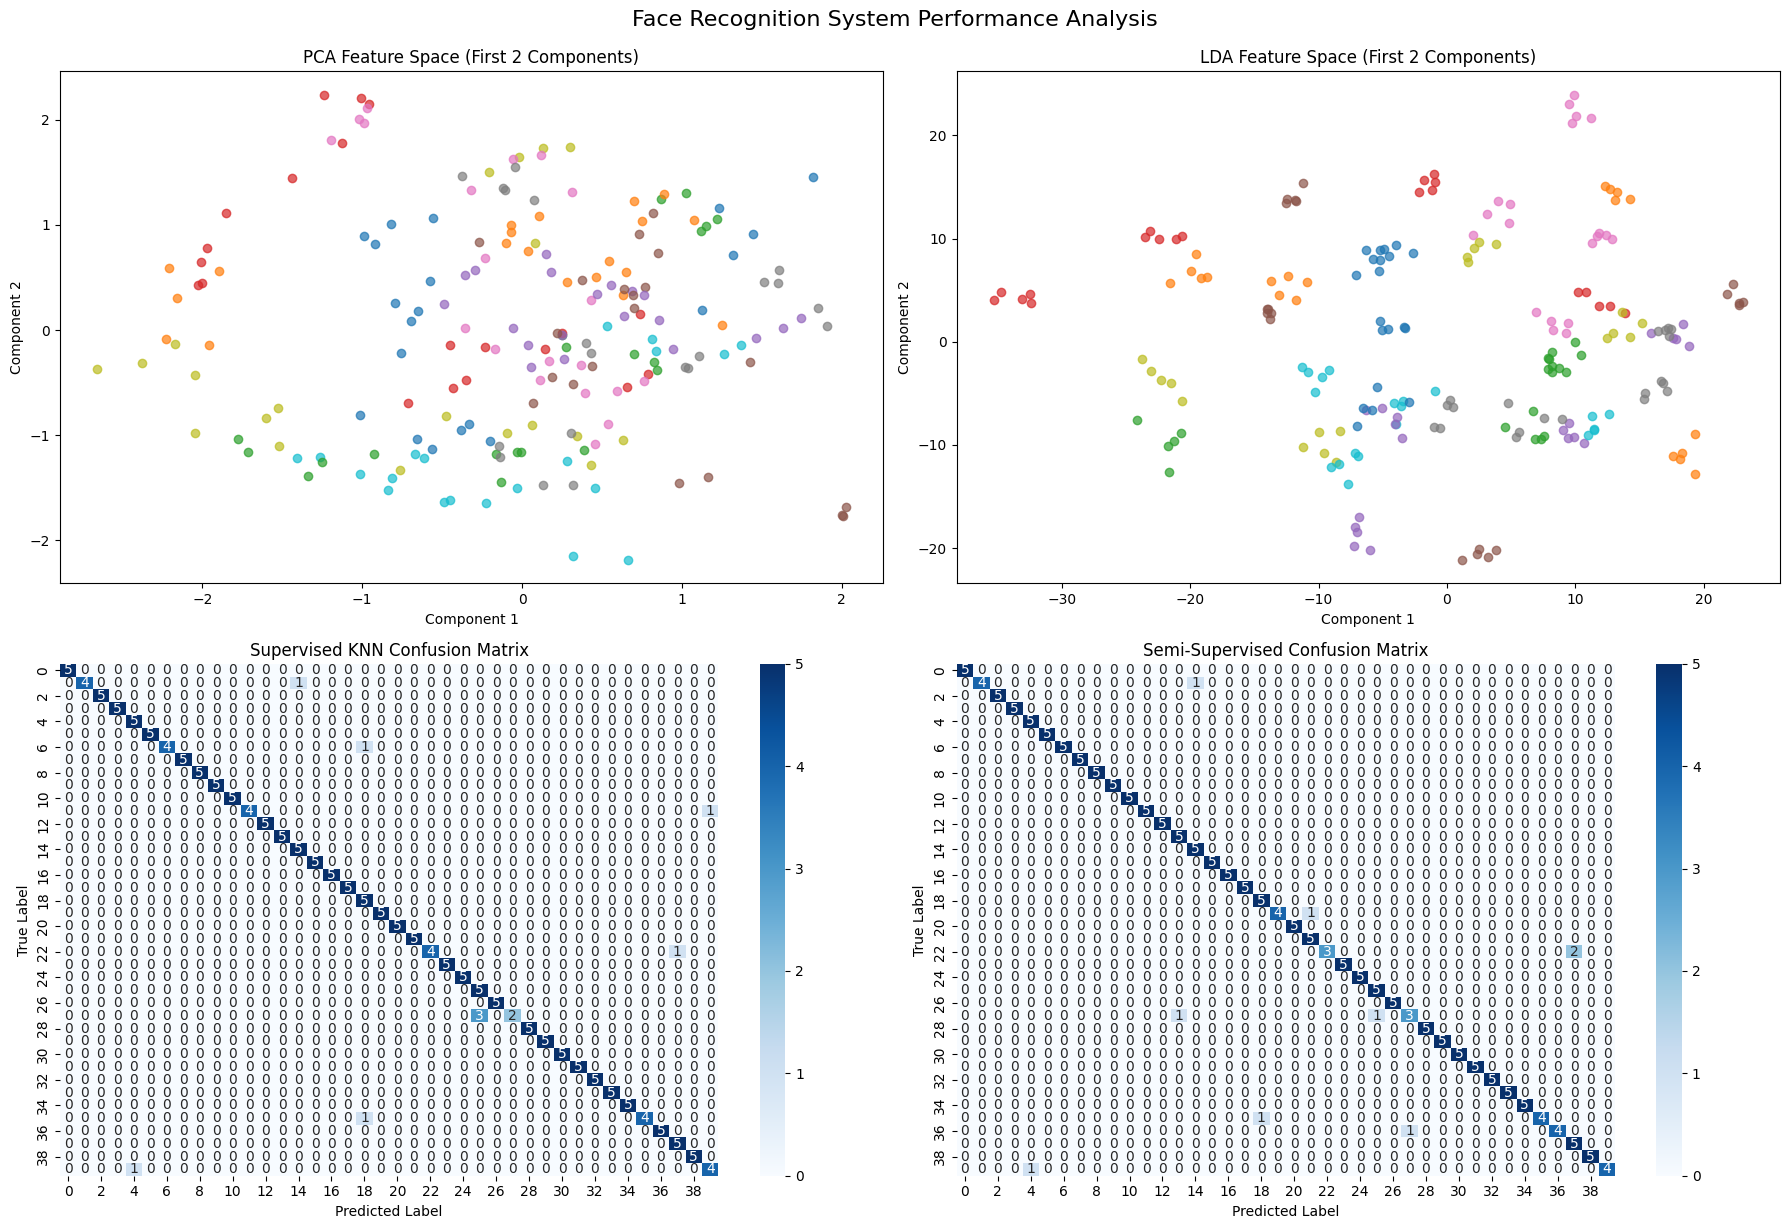

In [22]:

# =================================================================
# Enhanced Visualization
# =================================================================
plt.figure(figsize=(18, 12))

# Plot feature spaces
plt.subplot(2, 2, 1)
for i in np.unique(y_train):
    plt.scatter(X_train_pca[y_train==i, 0], X_train_pca[y_train==i, 1], label=f'Person {i}', alpha=0.7)
plt.title('PCA Feature Space (First 2 Components)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.subplot(2, 2, 2)
for i in np.unique(y_train):
    plt.scatter(X_train_lda[y_train==i, 0], X_train_lda[y_train==i, 1], label=f'Person {i}', alpha=0.7)
plt.title('LDA Feature Space (First 2 Components)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Confusion matrices
plt.subplot(2, 2, 3)
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Supervised KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(2, 2, 4)
cm_semi = confusion_matrix(y_test, y_pred_semi)
sns.heatmap(cm_semi, annot=True, fmt='d', cmap='Blues')
plt.title('Semi-Supervised Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.suptitle("Face Recognition System Performance Analysis", y=1.02, fontsize=16)
plt.show()



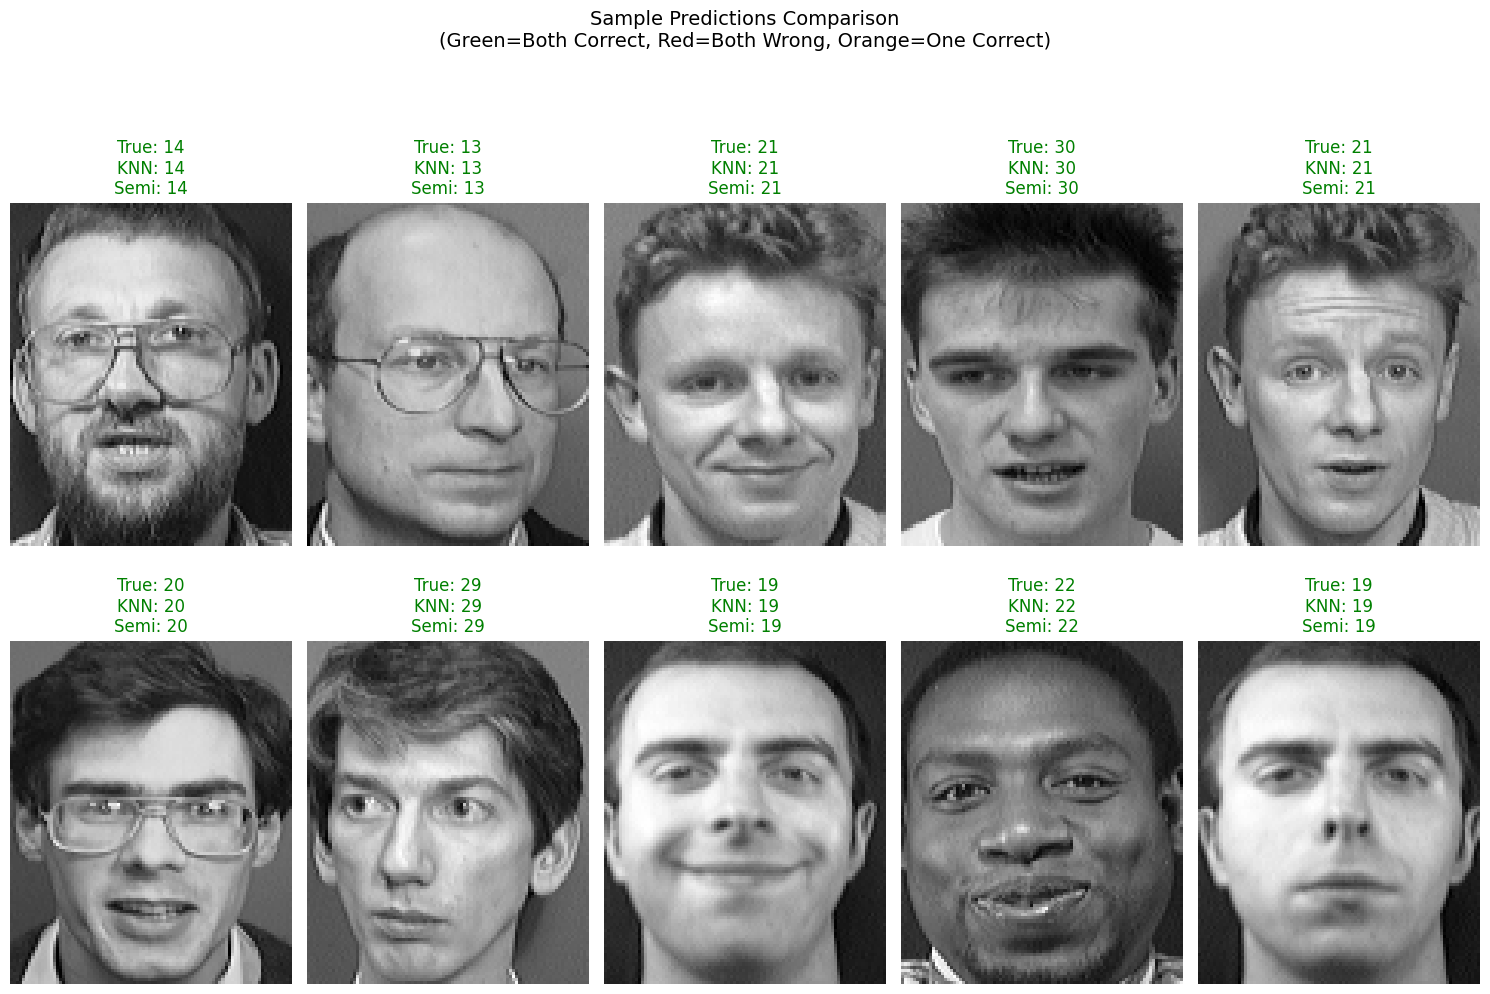

In [23]:
# =================================================================
# Sample Predictions Visualization
# =================================================================
plt.figure(figsize=(15, 10))
for i in range(10):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(img_height, img_width)

    # Get predictions from both models
    true_label = y_test[idx]
    knn_pred = y_pred_knn[idx]
    semi_pred = y_pred_semi[idx]

    # Create comparison string
    pred_text = f"True: {true_label}\nKNN: {knn_pred}\nSemi: {semi_pred}"

    # Determine color (green if both correct, red if both wrong, orange if one correct)
    if knn_pred == true_label and semi_pred == true_label:
        color = 'green'
    elif knn_pred != true_label and semi_pred != true_label:
        color = 'red'
    else:
        color = 'orange'

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(pred_text, color=color)
    plt.axis('off')

plt.suptitle("Sample Predictions Comparison\n(Green=Both Correct, Red=Both Wrong, Orange=One Correct)",
             y=1.05, fontsize=14)
plt.tight_layout()
plt.show()